🏆 MEJOR CONFIGURACIÓN:
iterations             8.000000
prominence_val         7.000000
min_width_hz       10000.000000
max_width_hz      200000.000000
mean_ppm               8.771091
std_ppm                3.512641
Name: 72, dtype: float64
------------------------------
💀 PEOR CONFIGURACIÓN:
iterations             5.000000
prominence_val         3.000000
min_width_hz       25000.000000
max_width_hz      200000.000000
mean_ppm             -34.577837
std_ppm               24.472190
Name: 33, dtype: float64


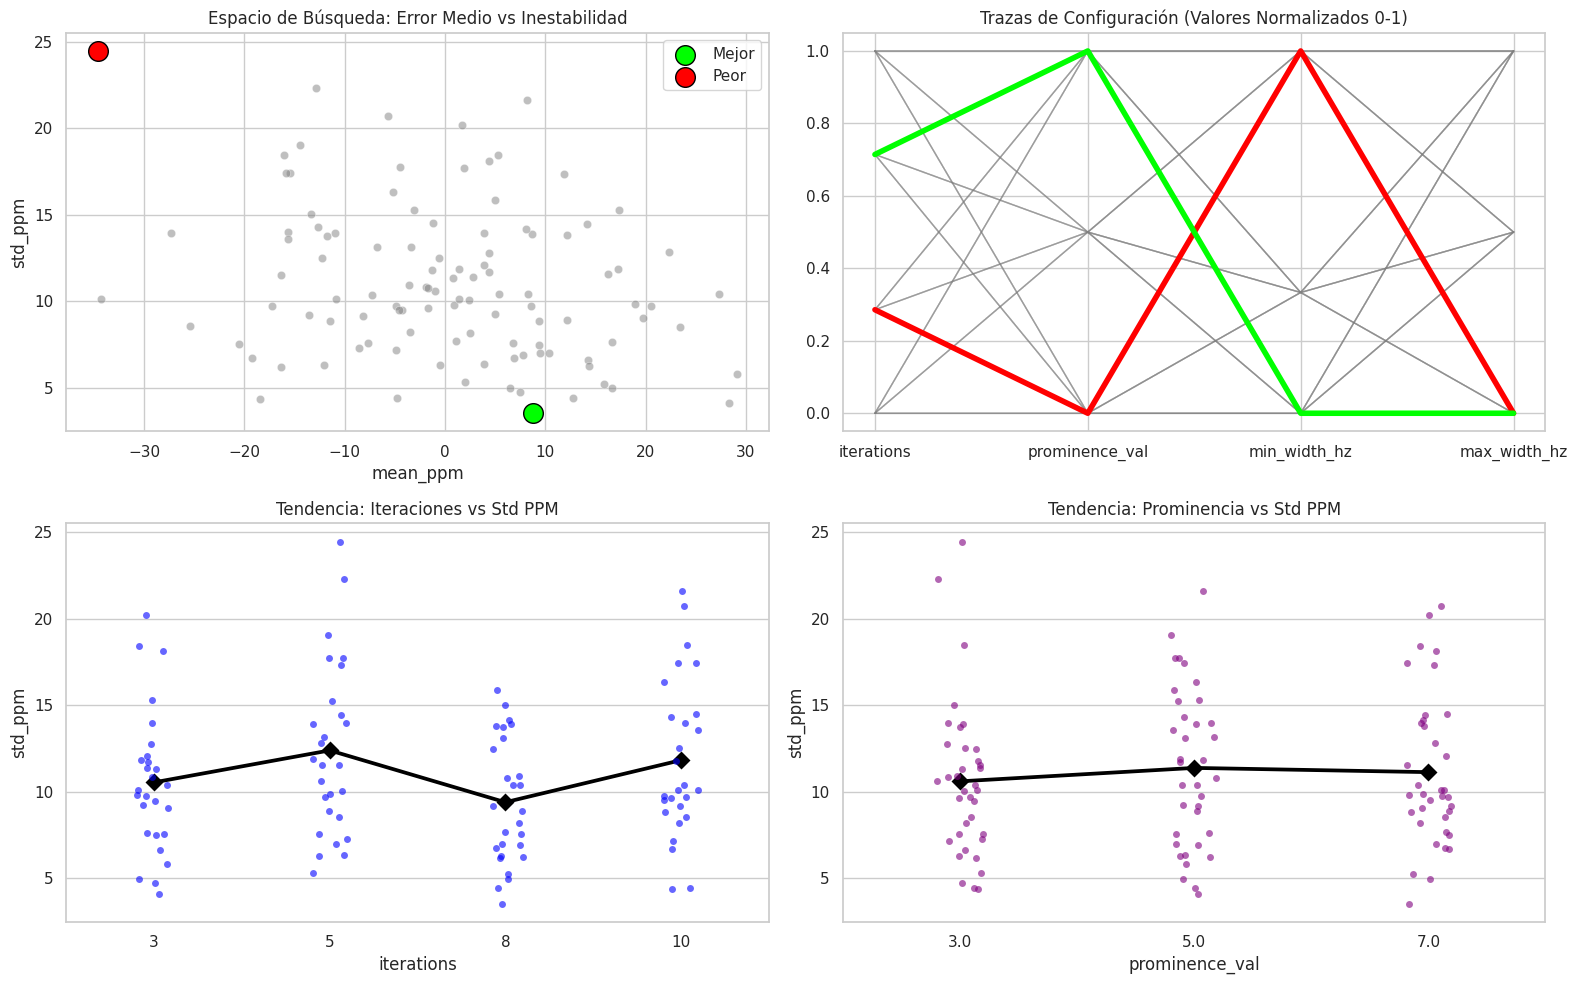

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Cargar datos
df = pd.read_csv("optimization_results.csv")
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(subset=['std_ppm'], inplace=True)

# Buscar el Mejor y Peor caso absoluto
best_idx = df['std_ppm'].idxmin()
worst_idx = df['std_ppm'].idxmax()
best = df.loc[best_idx]
worst = df.loc[worst_idx]

print("🏆 MEJOR CONFIGURACIÓN:")
print(best)
print("-" * 30)
print("💀 PEOR CONFIGURACIÓN:")
print(worst)

# Dibujar
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(16, 10))

# 1. Scatter General (Mean vs Std) con Best/Worst destacados
ax1 = plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x='mean_ppm', y='std_ppm', color='gray', alpha=0.5, ax=ax1)
ax1.scatter(best['mean_ppm'], best['std_ppm'], color='lime', edgecolor='black', s=200, label='Mejor', zorder=5)
ax1.scatter(worst['mean_ppm'], worst['std_ppm'], color='red', edgecolor='black', s=200, label='Peor', zorder=5)
ax1.set_title('Espacio de Búsqueda: Error Medio vs Inestabilidad')
ax1.legend()

# 2. Trazas de Parámetros (Coordenadas Paralelas)
ax2 = plt.subplot(2, 2, 2)
cols = ['iterations', 'prominence_val', 'min_width_hz', 'max_width_hz']
# Normalizar de 0 a 1 para visualizar juntos
df_norm = (df[cols] - df[cols].min()) / (df[cols].max() - df[cols].min())

for i, row in df_norm.iterrows():
    if i == best_idx:
        ax2.plot(cols, row[cols], color='lime', linewidth=4, zorder=10)
    elif i == worst_idx:
        ax2.plot(cols, row[cols], color='red', linewidth=4, zorder=9)
    else:
        ax2.plot(cols, row[cols], color='gray', alpha=0.15, linewidth=1)
ax2.set_title('Trazas de Configuración (Valores Normalizados 0-1)')

# 3. Iteraciones vs Estabilidad
ax3 = plt.subplot(2, 2, 3)
sns.stripplot(data=df, x='iterations', y='std_ppm', jitter=True, alpha=0.6, color='blue', ax=ax3)
sns.pointplot(data=df, x='iterations', y='std_ppm', color='black', markers="D", ax=ax3, errorbar=None)
ax3.set_title('Tendencia: Iteraciones vs Std PPM')

# 4. Prominencia vs Estabilidad
ax4 = plt.subplot(2, 2, 4)
sns.stripplot(data=df, x='prominence_val', y='std_ppm', jitter=True, alpha=0.6, color='purple', ax=ax4)
sns.pointplot(data=df, x='prominence_val', y='std_ppm', color='black', markers="D", ax=ax4, errorbar=None)
ax4.set_title('Tendencia: Prominencia vs Std PPM')

plt.tight_layout()
plt.show()